In [6]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm

import sys
sys.path.append('../../')

from codebase.subgroup_analysis import annotate_subgroups_framewise, assign_state_variable_and_get_transitions, convert_to_focal_distance, get_num_neighbours, _generate_sum_partitions
from codebase.parameter_fitting import get_polarization_by_subgroup_size

In [ ]:
exp_details = pd.read_csv('../../Data/groups_by_age/exp_details.csv')
data_path = '../../Data/groups_by_age/h5_files_cleaned/'

fish_ages = [2,4,6,8]
bodylengths = [4,7,10,12] # mm, from Zada et. al. 2024 
nfish = 4
L = 50 #mm

states_list_og = _generate_sum_partitions(nfish)
#switch order of [2,2] and [1,3]
order = [0,1,3,2,4]
states_list = [states_list_og[i] for i in order]
Nstates = len(states_list)

In [3]:
agewise_focal_distances_all_exp = []
agewise_num_neighbours_all_exp = []
agewise_sys_state_var_all_exp = []
agewise_sys_state_transitions_all_exp = []
agewise_subgroup_polarization_by_size_all_exp = []

for j,age in enumerate(fish_ages):
    exp_list = np.flatnonzero(exp_details['fish_age']==age)    
    
    focal_distances_all = []
    num_neighbours_all = []
    sys_state_var_all = []
    sys_state_transitions_all = np.zeros((len(exp_list),Nstates,Nstates))
    subgroup_polarization_by_size_all = {n:[] for n in range(2,nfish+1)}

    for i,exp in enumerate(exp_list):
        fpath = f'{data_path}{exp_details["experiment"][exp]}.h5'
        f = h5py.File(fpath,'r')
        x = f['tracks'][:nfish,0,:,:] # array of shape (fish x nodes x frames)
        y = f['tracks'][:nfish,1,:,:]
        nose_x = (x[:,0,:] + x[:,1,:])/2 # avg L and R eye positions to get nose position
        nose_y = (y[:,0,:] + y[:,1,:])/2
        # heading angles by calculating angle between nose and mid-bladder (node index 3)
        # mid-bladder is a more stable reference point than tail 
        head_angles = np.arctan2(nose_y - y[:,3,:], nose_x - x[:,3,:])

        # compute number of neighbours for each fish in the experiment
        num_neighbours_all.append(get_num_neighbours(nose_x, nose_y, L))

        # compute focal distances for each fish in the experiment
        for fi in range(nfish):
            dFB, dLR = convert_to_focal_distance(fi,nose_x,nose_y,head_angles)
            nan_mask = np.isfinite(dLR+dFB)
            focal_distances_all.append(np.column_stack((dLR[nan_mask], dFB[nan_mask])))

        # compute system state variable and transitions for the experiment
        sys_state_var, sys_state_transitions = assign_state_variable_and_get_transitions(nose_x, nose_y, L, states_list)
        sys_state_var_all.append(sys_state_var)
        sys_state_transitions_all[i,:,:] = sys_state_transitions

        # annotate subgroups 
        subgroups, start_end_frames = annotate_subgroups_framewise(nose_x, nose_y, L)
        subgroup_sizes = np.array([len(s) for s in subgroups])
        selected_idx = np.flatnonzero(subgroup_sizes > 1) 
        subgroups = [subgroups[idx] for idx in selected_idx]
        start_end_frames = start_end_frames[selected_idx,:]
        # polarization by subgroup size
        polarization_by_size = get_polarization_by_subgroup_size(subgroups, start_end_frames, head_angles)
        for n in range(2,nfish+1):
            if n in polarization_by_size:
                polarization_pooled = np.concatenate(polarization_by_size[n], axis=0)
                m_x = polarization_pooled[:,0]
                m_y = polarization_pooled[:,1]
                subgroup_polarization_by_size_all[n].append(np.sqrt(m_x**2 + m_y**2))        

    # pool data from all experiments of the same age
    agewise_num_neighbours_all_exp.append(np.concatenate(num_neighbours_all))
    agewise_focal_distances_all_exp.append(np.concatenate(focal_distances_all))
    agewise_sys_state_var_all_exp.append(np.concatenate(sys_state_var_all))
    agewise_subgroup_polarization_by_size_all_exp.append({n:np.concatenate(subgroup_polarization_by_size_all[n]) for n in range(2,nfish+1)})
    # calculate transition probabilities by pooling data
    transitions_summed =  np.sum(sys_state_transitions_all, axis=0)
    for mm in range(Nstates):
        transitions_summed[mm,mm] = np.nan
    #normalize by total number of transitions of each state
    transition_matrix = transitions_summed/ np.tile(np.nansum(transitions_summed,axis=1).reshape(-1,1),(1,Nstates))
    agewise_sys_state_transitions_all_exp.append(transition_matrix)

### Save analysis results

In [4]:
import pickle

with open('../../Results/experiments_subgroup_analysis_results.pkl', 'wb') as f:
    pickle.dump({
        'focal_distances': agewise_focal_distances_all_exp,
        'num_neighbours': agewise_num_neighbours_all_exp,
        'sys_state_var': agewise_sys_state_var_all_exp,
        'sys_state_transitions': agewise_sys_state_transitions_all_exp,
        'subgroup_polarization_by_size': agewise_subgroup_polarization_by_size_all_exp
    }, f)

# Plots results

#### Spatial densit plot for each age


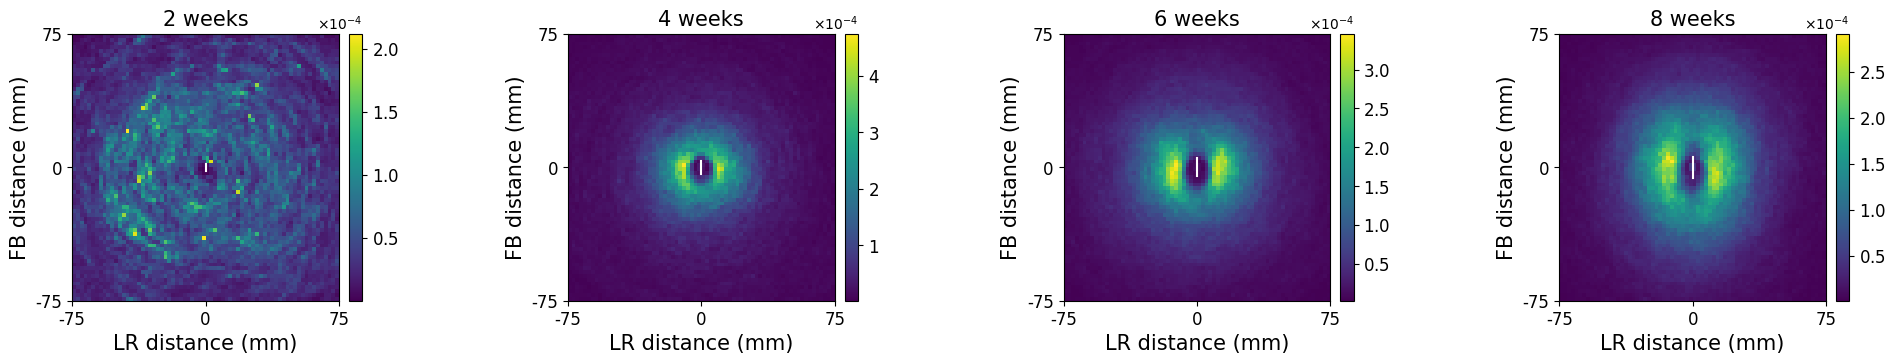

In [30]:
plot_lims = [75,75,75,75]
c_lims = [[0,0.0002],[0,0.0005],[0,0.0003],[0,0.0003]]

fig,ax = plt.subplots(1,4,figsize=(20,4))
for j,age in enumerate(fish_ages):
    dLR_all = agewise_focal_distances_all_exp[j][:,0]
    dFB_all = agewise_focal_distances_all_exp[j][:,1]
    lim = plot_lims[j]
    bl = bodylengths[j]

    bins = np.linspace(-lim,lim,71)
    
    im=ax[j].hist2d(dLR_all,dFB_all, cmap='viridis',bins=bins,density=True)
    #get colorbar of the right height
    divider = make_axes_locatable(ax[j])
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust the size and pad as needed
    cbar = plt.colorbar(im[3], cax=cax)
    ax[j].plot([0,0],[-bl/2,bl/2],color='w')
    #cbar.set_label('PDF',fontsize=15)
    #cbar.set_ticks([0,c_lims[j][1]/2,c_lims[j][1]])
    cbar.ax.tick_params(labelsize=12)
    cbar.formatter.set_powerlimits((0, 0))
    cbar.formatter.set_useMathText(True)
    title = f"{fish_ages[j]} weeks"
    ax[j].set_title(title,fontsize=15)
    ax[j].set_xlim([bins[0],bins[-1]])
    ax[j].set_ylim([bins[0],bins[-1]])
    ax[j].set_yticks([-lim,0,lim])
    ax[j].set_yticklabels(ax[j].get_yticks(),fontsize=12)
    ax[j].set_xticks([-lim,0,lim])
    ax[j].set_xticklabels(ax[j].get_xticks(),fontsize=12)
    ax[j].set_xlabel('LR distance (mm)',fontsize=15)
    ax[j].set_ylabel('FB distance (mm)',fontsize=15)
    ax[j].set_aspect('equal')
    
fig.tight_layout(pad=2)

### Number of interacting neighbors

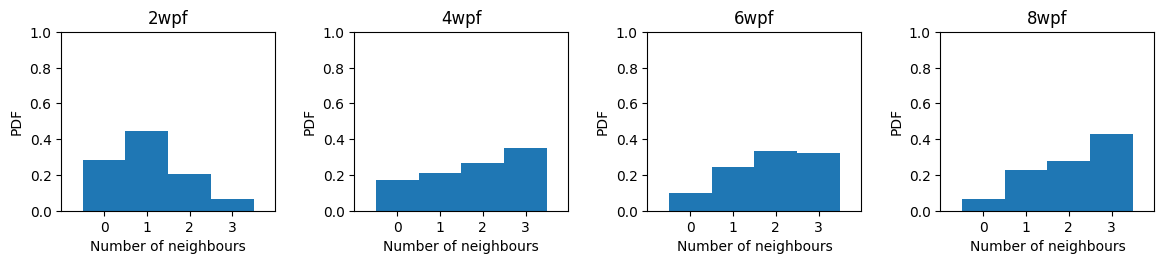

In [5]:
fig,ax = plt.subplots(1,4,figsize=(12,3))
for j,age in enumerate(fish_ages):
    neighbours_all = agewise_num_neighbours_all_exp[j]
    bins = -0.5 + np.arange(nfish+1)
    ax[j].hist(neighbours_all, bins=bins, density=True)
    title = f"{fish_ages[j]}wpf"
    ax[j].set_title(title)
    ax[j].set_xlim([-1,nfish])
    ax[j].set_ylim([0,1])
    #ax.set_yticks([-lim,0,lim])
    ax[j].set_xticks(range(nfish))
    ax[j].set_xlabel('Number of neighbours')
    ax[j].set_ylabel('PDF')
    
fig.tight_layout(pad=2)

### Subgroup configurations probability

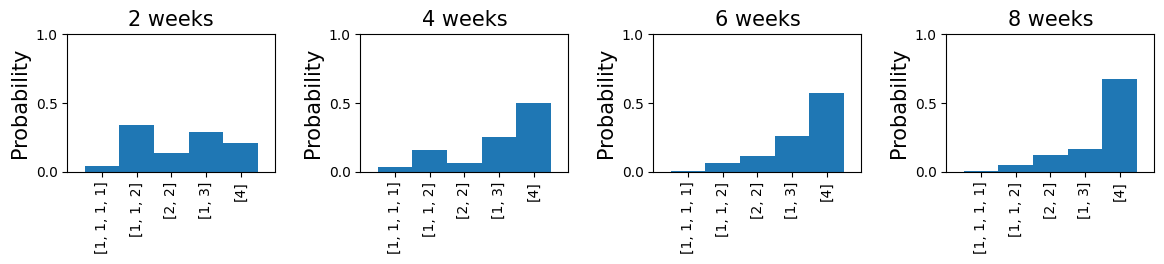

In [7]:
fig, ax = plt.subplots(1,len(fish_ages), figsize=(len(fish_ages)*3,3)) #probability of each state
for j,age in enumerate(fish_ages):

    #plot probability distribution of all states 
    ticks = [f"{states_list[n]}" for n in range(Nstates)]
    bins = np.arange(0,Nstates+1)-0.5
    sys_state_var = agewise_sys_state_var_all_exp[j]
    ax[j].hist(sys_state_var,bins=bins,density=True)
    ax[j].set_ylabel('Probability',fontsize=15)
    ax[j].set_title(f"{fish_ages[j]} weeks",fontsize=15)
    ax[j].set_xlim([-1,Nstates])
    ax[j].set_xticks(range(Nstates),ticks,rotation=90,fontsize=10)
    ax[j].set_yticks([0,0.5,1])
    ax[j].set_yticklabels(ax[j].get_yticks(),fontsize=10)
    ax[j].set_ylim([0,1])
fig.tight_layout(pad=2)

### Subgroup configurations transition probabilities

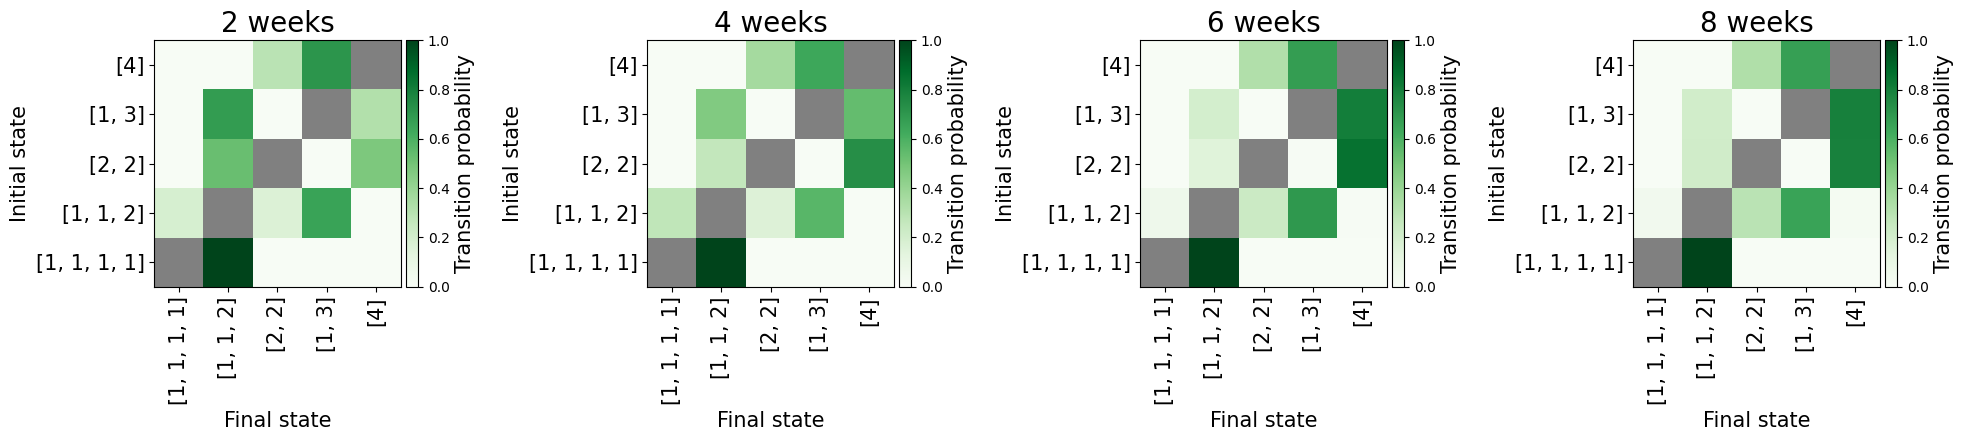

In [8]:
fig, ax = plt.subplots(1,len(fish_ages), figsize=(len(fish_ages)*5,7)) #transition probability without diagonal 

for j,age in enumerate(fish_ages):    
    mat = agewise_sys_state_transitions_all_exp[j]
    im=ax[j].imshow(mat,origin='lower',cmap='Greens')
    ax[j].set_facecolor((0.5,0.5,0.5))
    ax[j].set_xlim([-0.5,Nstates-0.5])
    ax[j].set_ylim([-0.5,Nstates-0.5])
    ax[j].set_xticks(np.arange(Nstates),ticks,rotation=90,fontsize=15)
    ax[j].set_yticks(np.arange(Nstates),ticks,fontsize=15)
    ax[j].set_xlabel("Final state",fontsize=15)
    ax[j].set_ylabel("Initial state",fontsize=15)
    #get colorbar of the right height
    divider = make_axes_locatable(ax[j])
    cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust the size and pad as needed
    cbar=fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=10) 
    #cbar.set_ticklabels(cax.get_yticks(),fontsize=10)
    cax.set_ylabel("Transition probability",fontsize=15)
    ax[j].set_title(f"{fish_ages[j]} weeks",fontsize=20)
    ax[j].set_aspect('equal')
fig.tight_layout(pad=2) 

### Steady state polarization distributions

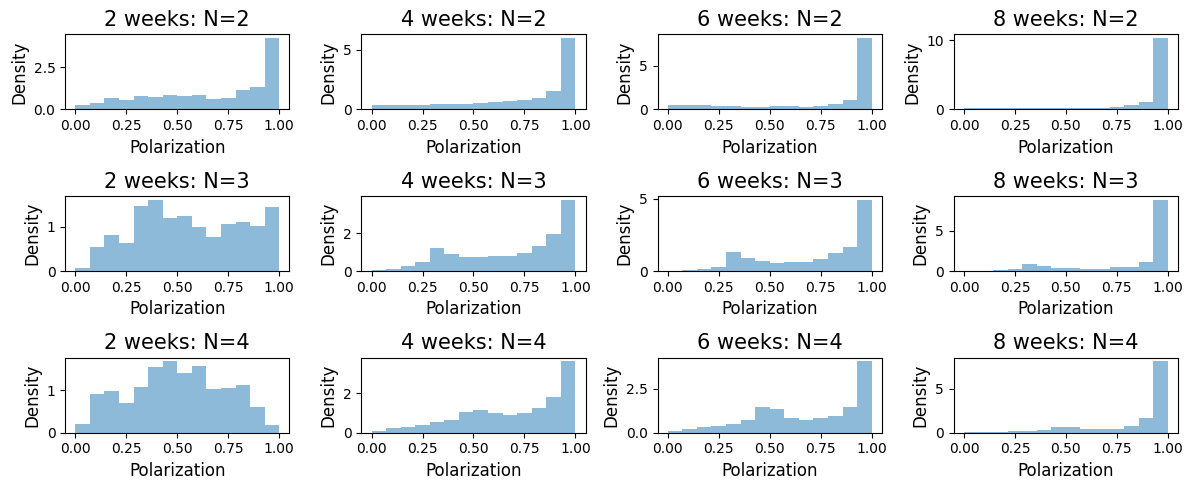

In [9]:
fig, ax = plt.subplots(3, len(fish_ages), figsize=(len(fish_ages)*3, 5)) #polarization      

for j, age in enumerate(fish_ages):
    polarization_dict = agewise_subgroup_polarization_by_size_all_exp[j]
    bins = np.linspace(0, 1, 15)  # bins for polarization histogram
    for i, (n,pol) in enumerate(polarization_dict.items()):
        ax[i,j].hist(pol, bins=bins, density=True, alpha=0.5, label=f'N={n}')
    
        ax[i,j].set_title(f"{age} weeks: N={n}", fontsize=15)
        ax[i,j].set_xlabel('Polarization', fontsize=12)
        ax[i,j].set_ylabel('Density', fontsize=12)

fig.tight_layout()